In [27]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Task 1: Load and Explore Data

In [28]:
# !pip install kagglehub
import kagglehub

# Download latest version
path = kagglehub.dataset_download("pratyushakar/rossmann-store-sales")

print("Path to dataset files:", path)

Path to dataset files: /Users/user/.cache/kagglehub/datasets/pratyushakar/rossmann-store-sales/versions/3


In [29]:
print("Files in dataset:")
for file in os.listdir(path):
    print(f" -{file}")
    file_size = os.path.getsize(os.path.join(path, file))
    print(f"   Size: {file_size / (1024 * 1024):.2f} MB")
# Load the data
train_df = pd.read_csv(os.path.join(path, "train.csv"))
test_df = pd.read_csv(os.path.join(path, "test.csv"))
store_df = pd.read_csv(os.path.join(path, "store.csv"))
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Store shape:", store_df.shape)



Files in dataset:
 -test.csv
   Size: 1.36 MB
 -train.csv
   Size: 36.29 MB
 -store.csv
   Size: 0.04 MB
Train shape: (1017209, 9)
Test shape: (41088, 8)
Store shape: (1115, 10)


/var/folders/2s/z3vdqv996cxdn9ktlygx85s40000gn/T/ipykernel_55461/3429277533.py:7: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv(os.path.join(path, "train.csv"))


In [47]:
#save raw data for later use in /Users/user/Desktop/Applied Projects/SC_forecast/data/raw
train_df.to_csv("/Users/user/Desktop/Applied Projects/SC_forecast/data/raw/train_raw.csv", index=False)
test_df.to_csv("/Users/user/Desktop/Applied Projects/SC_forecast/data/raw/test_raw.csv", index=False)
store_df.to_csv("/Users/user/Desktop/Applied Projects/SC_forecast/data/raw/store_raw.csv", index=False)

In [30]:
print("-- train_df null values --")
print(train_df.isnull().sum())
print("-- test_df null values --")
print(test_df.isnull().sum())
print("-- store_df null values --")
print(store_df.isnull().sum())

-- train_df null values --
Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64
-- test_df null values --
Id                0
Store             0
DayOfWeek         0
Date              0
Open             11
Promo             0
StateHoliday      0
SchoolHoliday     0
dtype: int64
-- store_df null values --
Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64


## Task 2: Key Data Understanding Questions

### #Store coverage:

#### How many unique stores are in training data? Test data?

In [31]:
print(f' We have {train_df["Store"].nunique()} unique stores in the training data.')
print(f' We have {test_df["Store"].nunique()} unique stores in the test data.')

 We have 1115 unique stores in the training data.
 We have 856 unique stores in the test data.


#### Are there stores in test that aren't in train?

In [32]:
# are the same stores in train and test?
train_stores = set(train_df["Store"].unique())
test_stores = set(test_df["Store"].unique())
common_stores = train_stores.intersection(test_stores)
print(f"Number of common stores in train and test: {len(common_stores)}")

Number of common stores in train and test: 856


### #Temporal coverage (critical for forecasting)

In [33]:
#convert date to datetime
train_df["Date"] = pd.to_datetime(train_df["Date"])

Text(0, 0.5, 'Total Sales')

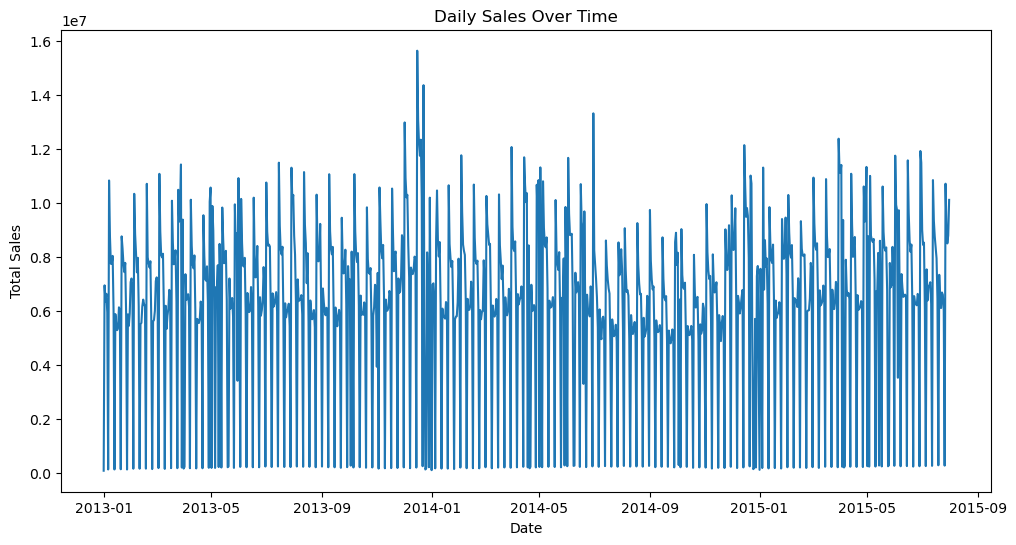

In [34]:
daily_sales = train_df.groupby("Date")["Sales"].sum().reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(data=daily_sales, x="Date", y="Sales")
plt.title("Daily Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")

In [35]:
date_range = pd.date_range(start=train_df["Date"].min(), end=train_df["Date"].max())
missing_dates = date_range[~date_range.isin(train_df["Date"])]
print(f"Missing dates in training data: {len(missing_dates)}")

Missing dates in training data: 0


### #Promotion analysis

   Promo         mean  median   count
0      0  4406.050805  4622.0  629129
1      1  7991.152046  7553.0  388080


Text(0, 0.5, 'Average Sales')

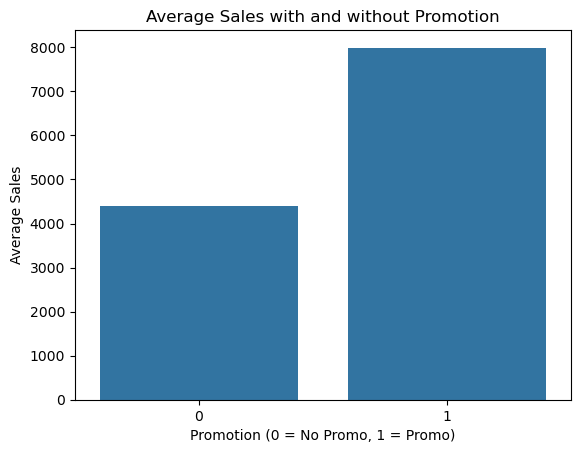

In [36]:
# Compare sales with and without promotions
promo_sales = train_df.groupby("Promo")["Sales"].agg(['mean', 'median', 'count']).reset_index()
print(promo_sales)
sns.barplot(data=promo_sales, x="Promo", y="mean")
plt.title("Average Sales with and without Promotion")
plt.xlabel("Promotion (0 = No Promo, 1 = Promo)")
plt.ylabel("Average Sales")

In [37]:
# Calculate promotion lift percentage
promo_lift = ((promo_sales.loc[promo_sales["Promo"] == 1, "mean"].values[0] - 
               promo_sales.loc[promo_sales["Promo"] == 0, "mean"].values[0]) / 
               promo_sales.loc[promo_sales["Promo"] == 0, "mean"].values[0]) * 100
print(f"Average promotion lift: {promo_lift:.2f}%")

Average promotion lift: 81.37%


Text(0, 0.5, 'Average Sales')

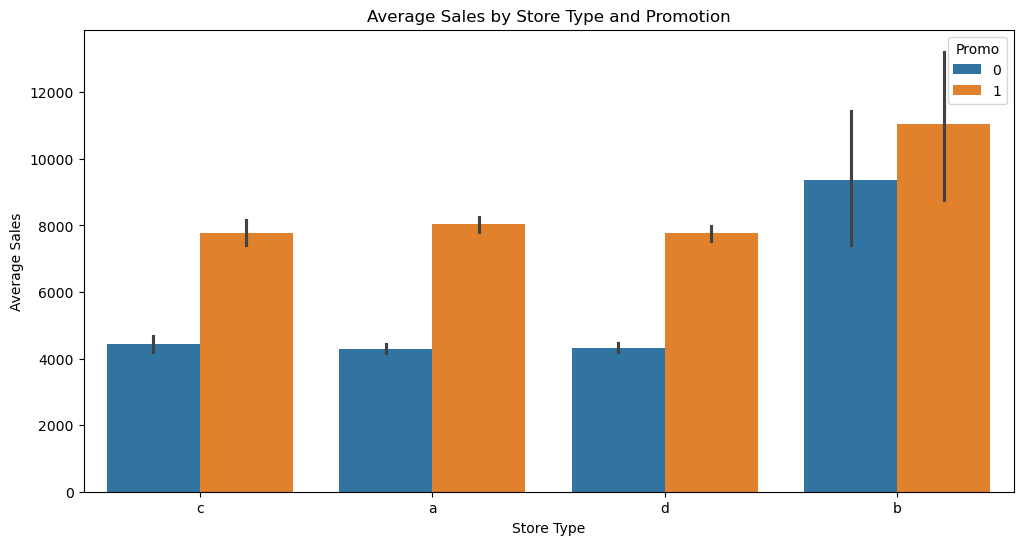

In [38]:
# Is the effect consistent across store types?
store_promo_sales = train_df.groupby(["Store", "Promo"])["Sales"].mean().reset_index()
store_promo_sales = store_promo_sales.merge(store_df[["Store", "StoreType"]], on="Store", how="left")
plt.figure(figsize=(12, 6))
sns.barplot(data=store_promo_sales, x="StoreType", y="Sales", hue="Promo")
plt.title("Average Sales by Store Type and Promotion")
plt.xlabel("Store Type")
plt.ylabel("Average Sales")

In [39]:
train_with_store = train_df.merge(store_df[['Store', 'StoreType']], on='Store', how='left')
promo_by_storetype = train_with_store.groupby(['StoreType', 'Promo'])['Sales'].mean().unstack()
promo_by_storetype['lift'] = (promo_by_storetype[1] - promo_by_storetype[0]) / promo_by_storetype[0] * 100
print(promo_by_storetype)

Promo                0             1       lift
StoreType                                      
a          4300.418175   8068.080939  87.611544
b          9409.434791  11109.739497  18.070211
c          4435.040156   7810.174738  76.101556
d          4326.661817   7776.593414  79.736567


### #Seasonality patterns

In [40]:
# Create features for analysis
train_df['DayOfWeek'] = train_df['Date'].dt.dayofweek
train_df['Month'] = train_df['Date'].dt.month
train_df['Year'] = train_df['Date'].dt.year
train_df['weekofyear'] = train_df['Date'].dt.isocalendar().week

Text(0, 0.5, 'Average Sales')

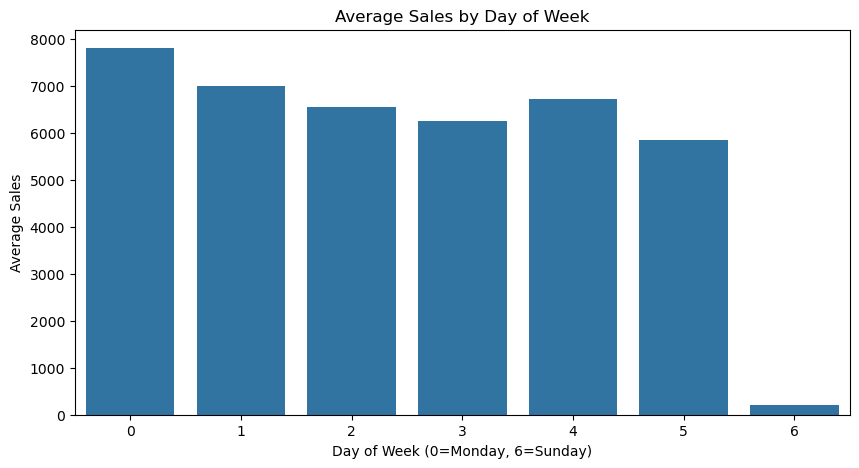

In [41]:
#weekly sales pattern
weekly_sales = train_df.groupby("DayOfWeek")["Sales"].mean().reset_index()
plt.figure(figsize=(10, 5))
sns.barplot(data=weekly_sales, x="DayOfWeek", y="Sales")
plt.title("Average Sales by Day of Week")
plt.xlabel("Day of Week (0=Monday, 6=Sunday)")
plt.ylabel("Average Sales")

Text(0, 0.5, 'Average Sales')

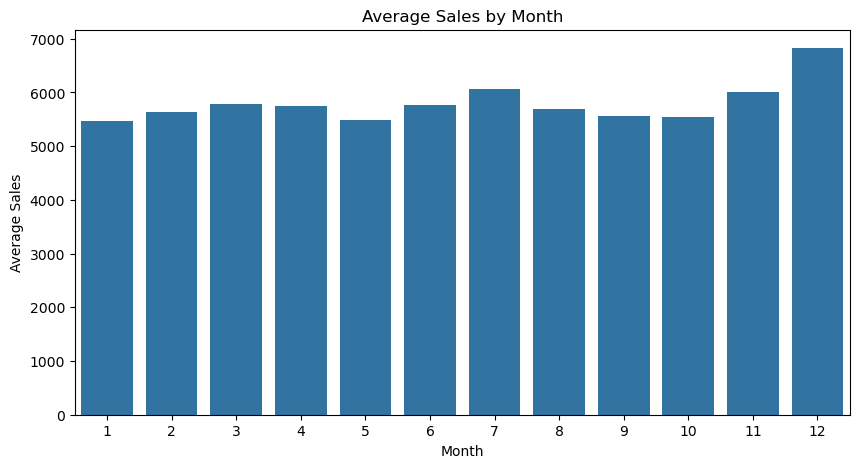

In [42]:
# Mmonthly sales pattern
monthly_sales = train_df.groupby("Month")["Sales"].mean().reset_index()
plt.figure(figsize=(10, 5))
sns.barplot(data=monthly_sales, x="Month", y="Sales")
plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Sales")

## Task 3: Handle the Test Data Challenge

**Important Business Insight:** The test set in Rossmann competition is NOT time-ordered after training data - it's a specific date range needed to predict.

In [26]:
# Are thre any stores in the test set that are not in the training set?
test_stores = set(test_df["Store"].unique())
train_stores = set(train_df["Store"].unique())
new_stores_in_test = test_stores - train_stores
print(f"Stores in test set not in training set: {len(new_stores_in_test)}")
print(f"New stores in test set: {new_stores_in_test}")

Stores in test set not in training set: 0
New stores in test set: set()


In [44]:
# Check test data dates
test_df["Date"] = pd.to_datetime(test_df["Date"])
test_date_range = pd.date_range(start=test_df["Date"].min(), end=test_df["Date"].max())
missing_test_dates = test_date_range[~test_date_range.isin(test_df["Date"])]
print(f"Missing dates in test data: {len(missing_test_dates)}")

Missing dates in test data: 0


In [45]:
# Are there gaps in the test data date range?
days_gap = (test_df['Date'].min() - train_df['Date'].max()).days
print(f"Days between training and test: {days_gap}")

Days between training and test: 1


In [51]:
pip install numpy

Note: you may need to restart the kernel to use updated packages.


In [49]:
train_max = pd.to_datetime(train_df['Date']).max()
test_min = pd.to_datetime(test_df['Date']).min()
gap = (test_min - train_max).days
print(f"Gap confirmed: {gap} day(s)")

Gap confirmed: 1 day(s)
